In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [2]:
import zipfile

zip_file = "archive (4).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [3]:
from torchvision.datasets import ImageFolder

In [4]:
import os

print(os.listdir())
print(os.listdir("mnist_png"))

['.config', 'archive (4).zip', 'mnist_png', 'sample_data']
['testing', 'training']


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [22]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    "mnist_png/training",
    transform=transform
)

test_dataset = ImageFolder(
    "mnist_png/testing",
    transform=transform
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 60000
Testing Images: 10000


In [7]:
def add_noise(images):
    noise = torch.randn_like(images) * 0.3
    noisy = images + noise
    return torch.clamp(noisy,0.,1.)

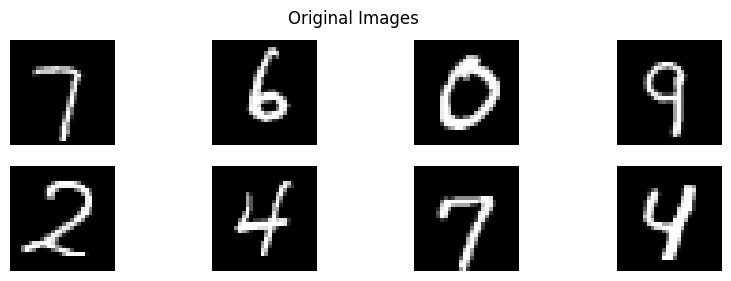

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,3))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis("off")

plt.suptitle("Original Images")
plt.show()

In [10]:
def add_noise(images, noise_factor=0.4):

    noise = torch.randn_like(images) * noise_factor

    noisy_images = images + noise

    noisy_images = torch.clamp(noisy_images,0.,1.)

    return noisy_images

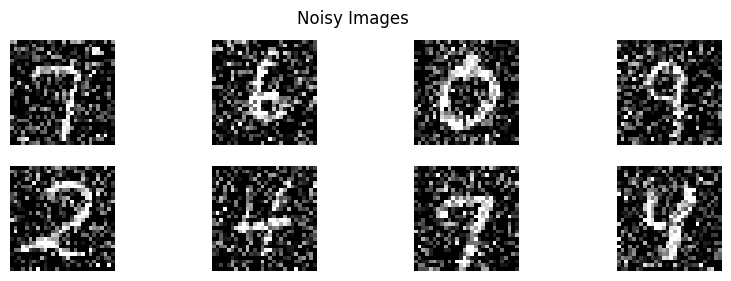

In [11]:
noisy = add_noise(images)

plt.figure(figsize=(10,3))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(noisy[i].squeeze(), cmap='gray')

    plt.axis("off")

plt.suptitle("Noisy Images")

plt.show()

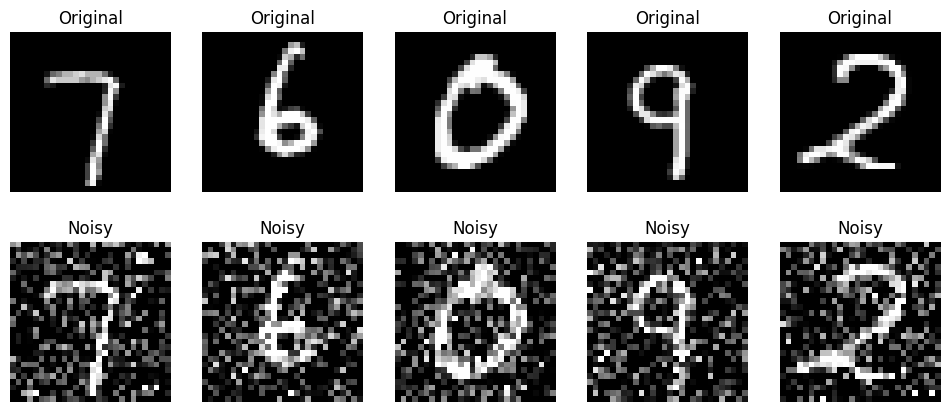

In [12]:
plt.figure(figsize=(12,5))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(noisy[i].squeeze(), cmap='gray')
    plt.axis("off")
    plt.title("Noisy")

plt.show()

In [13]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # ================= Encoder =================
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),

            nn.Conv2d(32, 64, kernel_size=7),
            nn.ReLU(True)
        )

        # ================= Decoder =================
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64, 32, kernel_size=7),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [16]:
model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


In [17]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 210369
Trainable Parameters : 210369


In [18]:
images, _ = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)

print("Output Shape:", outputs.shape)

Input Shape : torch.Size([128, 1, 28, 28])
Output Shape: torch.Size([128, 1, 28, 28])


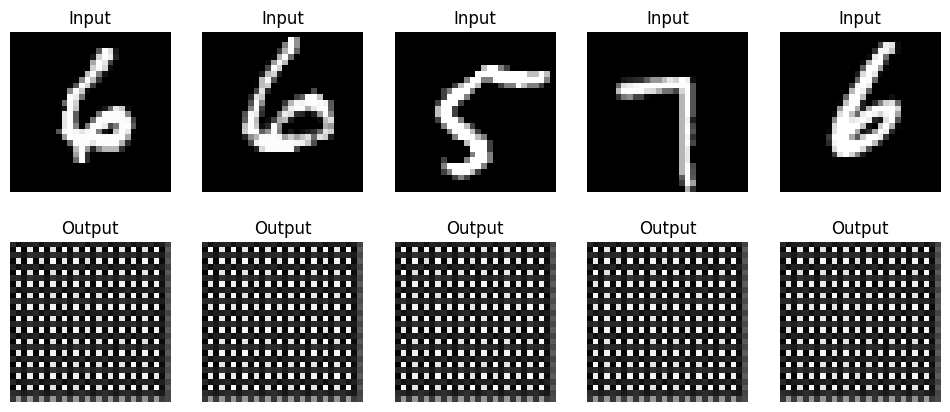

In [19]:
images, _ = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

images = images.cpu()

outputs = outputs.cpu()

plt.figure(figsize=(12,5))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Input")

    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Output")

plt.show()

In [20]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function :", criterion)

print("Optimizer :", optimizer)

Loss Function : MSELoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [23]:
num_epochs = 10

print("Batch Size :", batch_size)
print("Epochs :", num_epochs)
print("Learning Rate : 0.001")

Batch Size : 128
Epochs : 10
Learning Rate : 0.001


In [24]:
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []

In [25]:
model.train()

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        # Add noise
        noisy_images = add_noise(images)

        noisy_images = noisy_images.to(device)

        # Forward pass
        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

Epoch [1/10] Loss: 0.065882
Epoch [2/10] Loss: 0.023417
Epoch [3/10] Loss: 0.016169
Epoch [4/10] Loss: 0.014389
Epoch [5/10] Loss: 0.013543
Epoch [6/10] Loss: 0.012992
Epoch [7/10] Loss: 0.012422
Epoch [8/10] Loss: 0.012046
Epoch [9/10] Loss: 0.011797
Epoch [10/10] Loss: 0.011583


In [26]:
torch.save(model.state_dict(), "best_model.pth")

print("Model Saved Successfully!")

Model Saved Successfully!


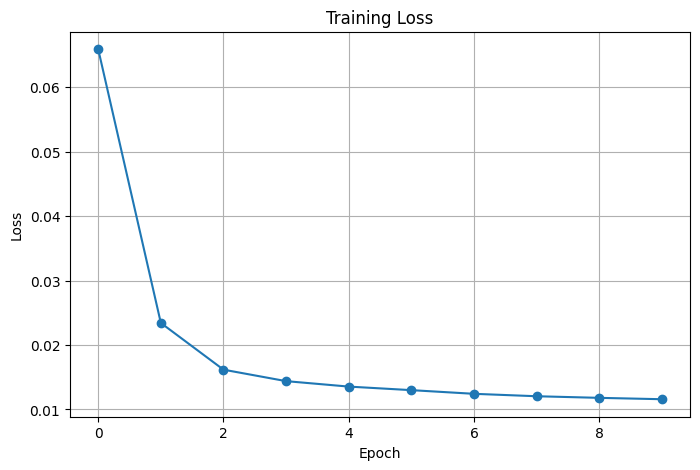

In [27]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

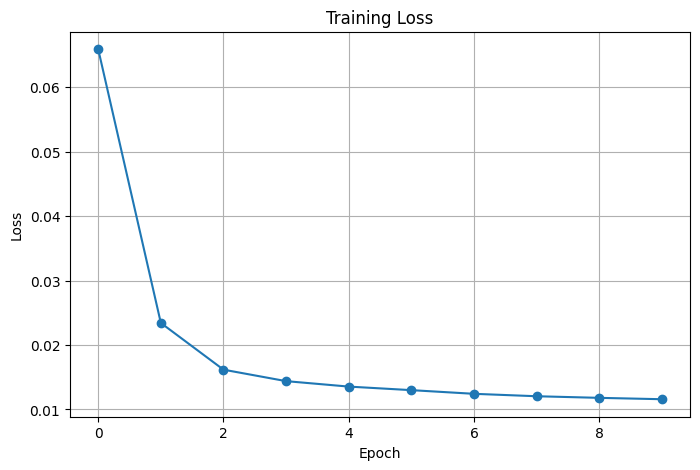

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.savefig("loss_curve.png")

plt.show()

In [29]:
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

In [30]:
images, _ = next(iter(test_loader))

images = images.to(device)

noisy_images = add_noise(images)

with torch.no_grad():
    reconstructed = model(noisy_images)

In [31]:
images = images.cpu()

noisy_images = noisy_images.cpu()

reconstructed = reconstructed.cpu()

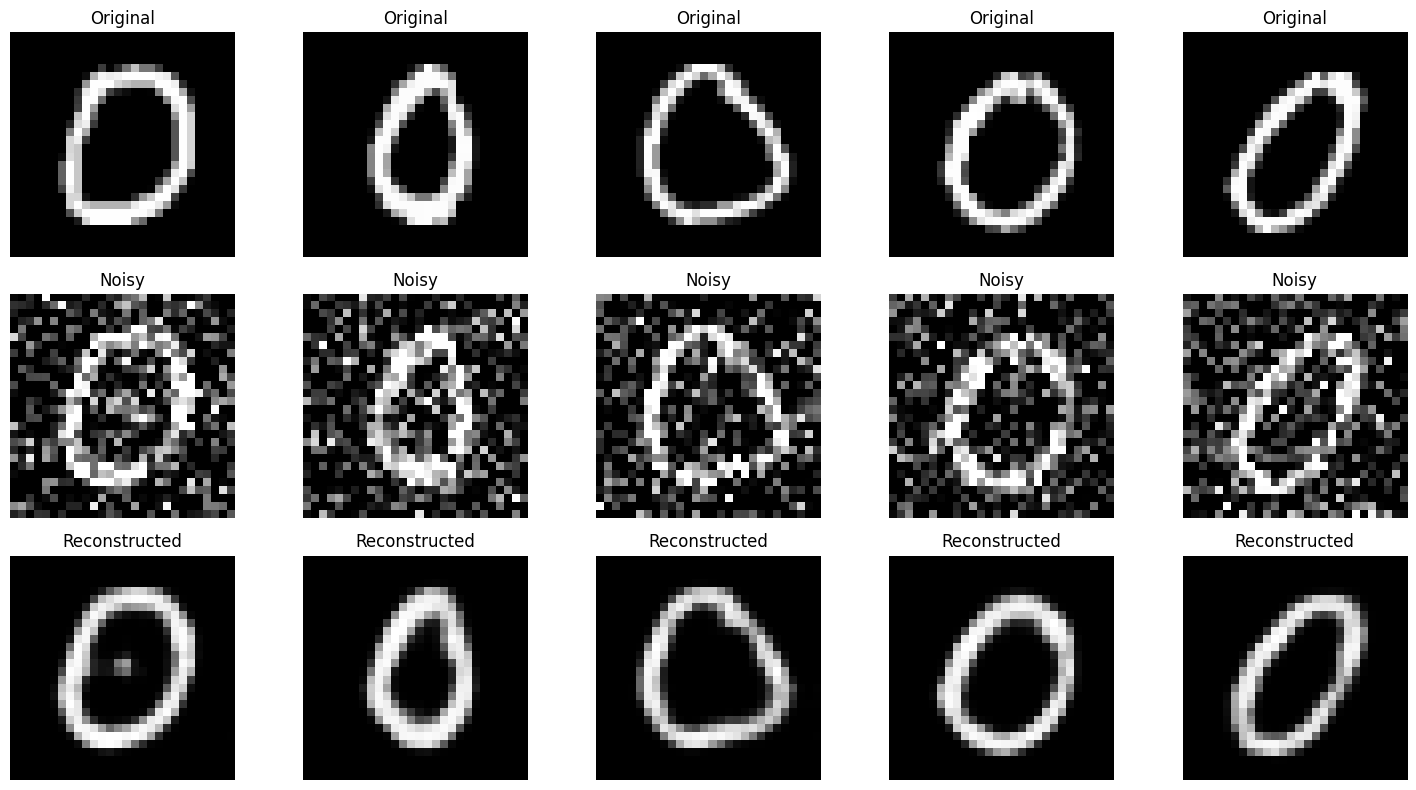

In [32]:
plt.figure(figsize=(15,8))

for i in range(5):

    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(3,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,5,i+11)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

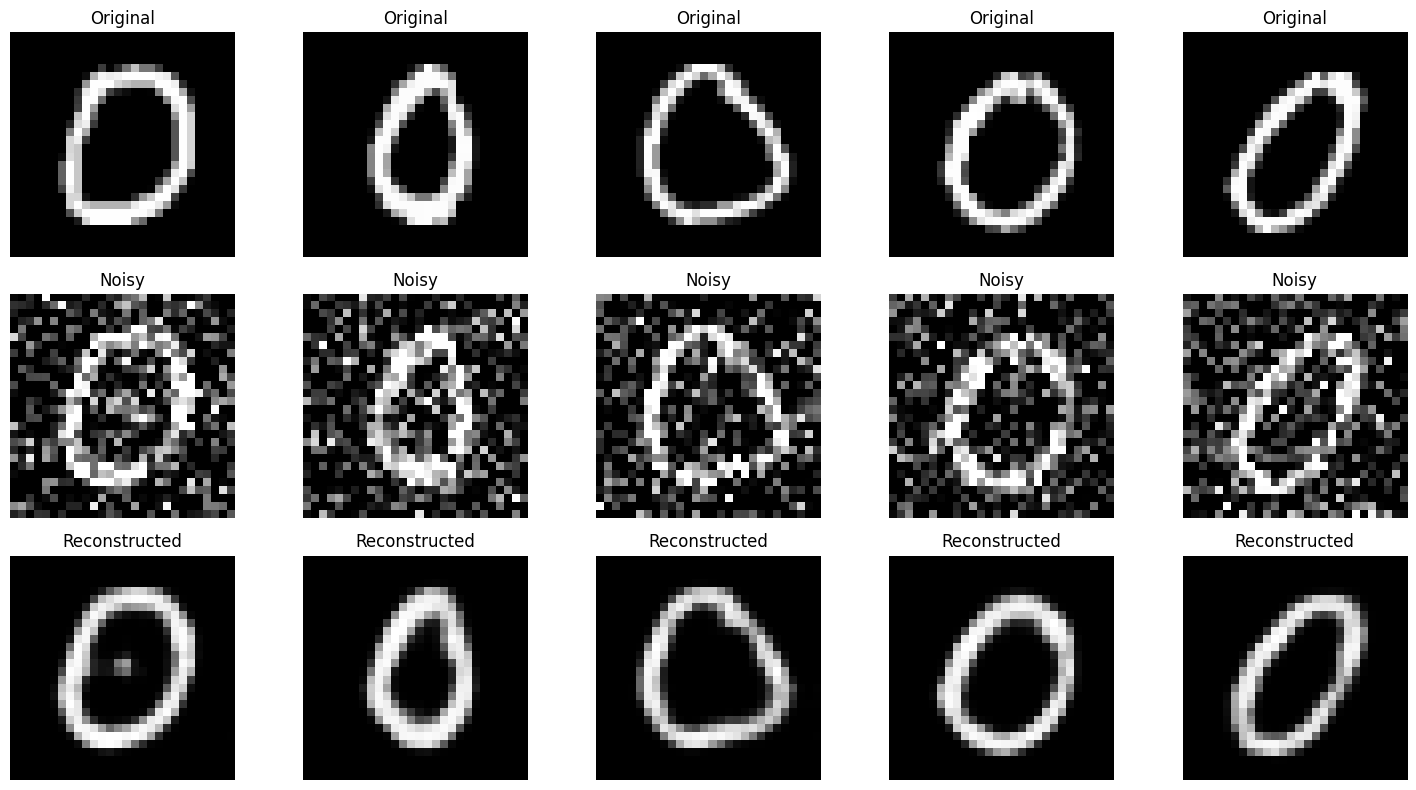

In [33]:
plt.figure(figsize=(15,8))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()

plt.savefig("reconstruction_results.png")

plt.show()

In [34]:
from google.colab import files

files.download("best_model.pth")
files.download("loss_curve.png")
files.download("reconstruction_results.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>